# Job Market Skills Analyzer

## 1. Project Objective
This project analyzes job posting data to find:
- The most common job roles (Main Roles)
- The most requested technical skills
- The distribution of work mode (Remote / Hybrid / On-site)
- The experience levels required

**Data Source:** [job_postings_raw+ Source: Kaggle — https://www.kaggle.com/datasets/lukebarousse/data-analyst-job-postings-google-search

**Route:** Approved Dataset (Route 1)

## 2. Imports and Settings
Import the required libraries and set up the file paths used in this project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sys
sys.path.append('src')

## 3. Data Loading
Load the raw data exactly as it is, with no changes, to keep the original file safe.

In [3]:
Job_postings_raw = pd.read_csv(r"C:\Users\FuTuTRe\Desktop\job_market_skills_analyzer\data\raw\Job_postings_raw.csv")
Job_postings_raw.head()

,Unnamed: 0,index,title,company_name,location,via,description,extensions,job_id,thumbnail,...,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens
0,0,0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']"
1,1,1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql']
3,3,3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,...,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']"
4,4,4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,...,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']"


## 4. Initial Inspection
Check the shape, columns, data types, missing values, and duplicates before any cleaning.

### Observations Before Cleaning:
- [ number of rows and columns ]
- [ which columns have missing values, and how many ]
- [ any duplicate rows found ]
- [ notes on messy text: extra spaces, inconsistent capitalization, etc. ]

In [4]:
Job_postings_raw.columns
Job_postings_raw["search_location"]

0        United States
1        United States
2        United States
3        United States
4        United States
             ...      
61948    United States
61949    United States
61950    United States
61951    United States
61952    United States
Name: search_location, Length: 61953, dtype: str

In [5]:
Job_postings_raw.shape

(61953, 27)

In [6]:
Job_postings_raw.describe()

,Unnamed: 0,index,commute_time,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized
count,61953.000000,61953.000000,0.0,10088.000000,9512.000000,9512.000000,5900.000000,4069.000000,10088.000000
mean,30976.000000,1139.077333,NaN,42100.231239,34846.281874,50487.856787,40.539588,104115.406718,92289.425683
std,17884.434951,690.256113,NaN,55893.993519,45843.034891,67366.522273,22.214540,36024.388492,43277.933820
min,0.000000,0.000000,NaN,7.250000,8.000000,10.000000,7.250000,29289.840000,15080.000000
25%,15488.000000,553.000000,NaN,31.500000,19.520000,45.000000,23.265000,80000.180000,62400.000000
50%,30976.000000,1111.000000,NaN,60.000000,50.000000,75.000000,33.500000,96500.000000,88400.000000
75%,46464.000000,1685.000000,NaN,92500.000000,77000.000000,110000.000000,55.000000,120000.000000,117500.000000
max,61952.000000,3228.000000,NaN,550000.000000,450000.000000,850000.000000,300.000000,550000.000000,624000.000000


In [7]:
Job_postings_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           61953 non-null  int64  
 1   index                61953 non-null  int64  
 2   title                61953 non-null  str    
 3   company_name         61953 non-null  str    
 4   location             61916 non-null  str    
 5   via                  61944 non-null  str    
 6   description          61953 non-null  str    
 7   extensions           61953 non-null  str    
 8   job_id               61953 non-null  str    
 9   thumbnail            38194 non-null  str    
 10  posted_at            61763 non-null  str    
 11  schedule_type        61707 non-null  str    
 12  work_from_home       27980 non-null  object 
 13  salary               10088 non-null  str    
 14  search_term          61953 non-null  str    
 15  date_time            61953 non-null  str    
 1

In [8]:
Job_postings_raw.isnull().sum()

Unnamed: 0                 0
index                      0
title                      0
company_name               0
location                  37
via                        9
description                0
extensions                 0
job_id                     0
thumbnail              23759
posted_at                190
schedule_type            246
work_from_home         33973
salary                 51865
search_term                0
date_time                  0
search_location            0
commute_time           61953
salary_pay             51865
salary_rate            51865
salary_avg             51865
salary_min             52441
salary_max             52441
salary_hourly          56053
salary_yearly          57884
salary_standardized    51865
description_tokens         0
dtype: int64

In [9]:
print(Job_postings_raw.duplicated())

print(f"\nNumber of duplicated = {Job_postings_raw.duplicated().sum()}")

0        False
1        False
2        False
3        False
4        False
         ...  
61948    False
61949    False
61950    False
61951    False
61952    False
Length: 61953, dtype: bool

Number of duplicated = 0


## 5. Data Cleaning
Clean column names, remove duplicate rows, and handle missing values using the functions in `src/data_utils.py`.

**Decision:** Duplicate rows were removed based on [job_title + company]. Column [X] was dropped because it had a very high percentage of missing values.

In [10]:
from data_utils import (
    clean_column_names,
    rename_columns,
    sample_data,
    fill_missing_from_column,
    drop_unused_columns,
    remove_duplicates,
    handle_missing_values,
    clean_text_columns,
    save_cleaned_data
)

# 5.1 Clean column names first
Job_postings_raw = clean_column_names(Job_postings_raw)

In [11]:
# 5.2 Rename to match required project fields
rename_map = {
    "title": "job_title",
    "company_name": "company",
    "description": "job_description",
    "schedule_type": "employment_type",
    "work_from_home": "work_mode",
    "posted_at": "posted_date",
    "via": "source"
}
Job_postings_raw = rename_columns(Job_postings_raw, rename_map)

[OK] Renamed 7 columns: {'title': 'job_title', 'company_name': 'company', 'description': 'job_description', 'schedule_type': 'employment_type', 'work_from_home': 'work_mode', 'posted_at': 'posted_date', 'via': 'source'}


In [12]:
# 5.3 Take a reproducible sample
Job_postings_raw = sample_data(Job_postings_raw, n=1000, random_state=42)

# 5.4 Fill location from search_location before dropping it
Job_postings_raw = fill_missing_from_column(
    Job_postings_raw, target_col="location", source_col="search_location"
)


[OK] Sampled 1000 rows out of 61953 (random_state=42)
[OK] Filled 0 missing 'location' values from 'search_location'


In [13]:
# 5.5 Drop unused columns
columns_to_drop = [
    "unnamed_0", "job_id", "thumbnail", "commute_time",
    "date_time", "search_term", "search_location",
    "salary_pay", "salary_avg", "salary_hourly", "salary_yearly" ,"index"
]
Job_postings_raw = drop_unused_columns(Job_postings_raw, columns_to_drop)

[OK] Dropped 12 unused columns: ['unnamed_0', 'job_id', 'thumbnail', 'commute_time', 'date_time', 'search_term', 'search_location', 'salary_pay', 'salary_avg', 'salary_hourly', 'salary_yearly', 'index']


In [14]:
# 5.6 Fill employment_type (only 4 missing values - safe to fill)
Job_postings_raw = handle_missing_values(
    Job_postings_raw, fill_value="Unknown", columns=["employment_type"]
)

# 5.7 Validate salary columns as proper numeric types (no invented values)
salary_cols = ["salary_min", "salary_max", "salary_standardized"]
for col in salary_cols:
    Job_postings_raw[col] = pd.to_numeric(Job_postings_raw[col], errors="coerce")


[INFO] Filled 4 missing values in 'employment_type' with 'Unknown'


In [15]:
# 5.8 Sanity check: flag any illogical salary rows (min > max)
invalid_salary = Job_postings_raw[
    Job_postings_raw["salary_min"] > Job_postings_raw["salary_max"]
]
print(f"[CHECK] Found {len(invalid_salary)} rows where salary_min > salary_max")

# 5.9 Create has_salary flag instead of inventing missing salary values
Job_postings_raw["has_salary"] = Job_postings_raw["salary_standardized"].notna()


[CHECK] Found 0 rows where salary_min > salary_max


In [16]:

# 5.10 Clean text columns
text_columns = ["job_title", "company", "location", "job_description", "source"]
Job_postings_raw = clean_text_columns(Job_postings_raw, text_columns)

# 5.11 Remove duplicate postings
Job_postings_raw = remove_duplicates(
    Job_postings_raw, subset=["job_title", "company", "location"]
)

# 5.12 Save the cleaned dataset
save_cleaned_data(Job_postings_raw, "data/cleaned/job_postings_cleaned.csv")

Job_postings_raw.head()

[OK] Removed 23 duplicate rows (1000 -> 977)
[OK] Saved cleaned dataset (977 rows) to data\cleaned\job_postings_cleaned.csv


,job_title,company,location,source,job_description,extensions,posted_date,employment_type,work_mode,salary,salary_rate,salary_min,salary_max,salary_standardized,description_tokens,has_salary
0,Senior Financial Analyst / Business Analyst / ...,Four Pillars Talent,United States,via KSNT Jobs,Senior Financial Analyst / Business Analyst / ...,"['19 hours ago', 'Full-time', 'Health insuranc...",19 hours ago,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,"['power_bi', 'tableau', 'excel', 'power_bi', '...",False
1,Data Analytics&Visualization Associate,JPMorgan Chase & Co.,United States,via Media Bistro,Job DescriptionIf you want to grow your career...,"['15 hours ago', 'Full-time', 'Health insuranc...",15 hours ago,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,"['tableau', 'dart', 'sql', 'r', 'alteryx']",False
2,Business Analyst/Scrum Master - REMOTE- Contra...,Queen Consulting Group,"Kansas City, MO",via ZipRecruiter,Position: Business Analyst/Scrum Master - cont...,"['18 hours ago', 'Full-time']",18 hours ago,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,[],False
3,Data Scientist,Thermo Fisher Scientific,Anywhere,via LinkedIn,"As a global leader in serving science, Thermo ...","['19 hours ago', 'Work from home', 'Full-time'...",19 hours ago,Full-time,True,NaN,NaN,NaN,NaN,NaN,"['aws', 'python']",False
4,Google Analytics 4 Setup and Dashboard,Upwork,Anywhere,via Upwork,I'm looking for a professional with deep exper...,"['24 hours ago', '50–75 an hour', 'Work from h...",24 hours ago,Contractor and Temp work,True,50–75 an hour,an hour,50.0,75.0,130000.0,[],True


In [17]:
Job_postings_raw.isnull().sum()

job_title                0
company                  0
location                 0
source                   0
job_description          0
extensions               0
posted_date              0
employment_type          0
work_mode              528
salary                 825
salary_rate            825
salary_min             834
salary_max             834
salary_standardized    825
description_tokens       0
has_salary               0
dtype: int64

## 6. Text Processing (Regex)
Extract skills, experience, and work mode from job_description using regex, since these are not fully available as separate fields in the source data.

In [18]:
from text_processing import (
    load_skills_list,
    add_skill_columns,
    add_experience_columns,
    add_work_mode_check_column,
    add_standardized_work_mode_column
)

# 6.1 Skills
skills_list = load_skills_list("config/skills_list.txt")
Job_postings_raw = add_skill_columns(Job_postings_raw, text_column="job_description", skills_list=skills_list)

# 6.2 Experience
Job_postings_raw = add_experience_columns(Job_postings_raw, text_column="job_description")

# 6.3 Work mode from text (our regex)
Job_postings_raw = add_work_mode_check_column(Job_postings_raw, text_column="job_description")

# 6.4 Standardize the existing work_mode column for a fair comparison
Job_postings_raw = add_standardized_work_mode_column(Job_postings_raw, source_column="work_mode")

# 6.5 Compare
match_rate = (Job_postings_raw["work_mode_standardized"] == Job_postings_raw["work_mode_from_text"]).mean() * 100
print(f"Work mode match rate: {match_rate:.1f}%")

pd.crosstab(Job_postings_raw["work_mode_standardized"], Job_postings_raw["work_mode_from_text"])

[OK] Loaded 20 skills from config/skills_list.txt
[OK] Added 20 skill indicator columns based on 'job_description'
[OK] Extracted experience info from 545 out of 977 rows
[OK] Added 'work_mode_from_text' column based on 'job_description'
[OK] Added 'work_mode_standardized' column standardized from 'work_mode'
Work mode match rate: 52.0%


work_mode_from_text,Hybrid,On-site,Remote,Unknown
work_mode_standardized,,,,
Remote,11,3,175,260
Unknown,86,26,83,333


In [19]:
pd.crosstab(Job_postings_raw["work_mode_standardized"], Job_postings_raw["work_mode_from_text"])

work_mode_from_text,Hybrid,On-site,Remote,Unknown
work_mode_standardized,,,,
Remote,11,3,175,260
Unknown,86,26,83,333


**Result:** Skills detected across 977 postings, experience information 
found in 56.7% of postings, and work mode matched 52.0% with the existing 
column. The original `work_mode` field only had two effective categories 
(Remote / Unknown), with no "On-site" values present. Our regex-based 
extraction additionally identified 86 "Hybrid" postings and 3 "On-site" 
postings that were not distinguishable in the original field - showing 
that the text-based extraction added information beyond what was 
originally available.

## 7. Feature Engineering

Build new columns from the cleaned and processed data: a standardized 
main job role, a skill count, and a seniority level extracted from the 
job title.

In [20]:
Job_postings_raw["job_title"].unique()

<ArrowStringArray>
[      'Senior Financial Analyst / Business Analyst / Data Analyst – Remote',
                                    'Data Analytics&Visualization Associate',
                 'Business Analyst/Scrum Master - REMOTE- Contract to Perm!',
                                                            'Data Scientist',
                                    'Google Analytics 4 Setup and Dashboard',
                                            'Marketing Analytics Consultant',
                                                    'Need actuarial analyst',
                  'Lead Data Analyst, Integrated Business Planning (Remote)',
         '2024 Summer Intern: Master's Sam's Club Supply Chain Data Analyst',
                    'Fall Co-Op - Defense and Special Missions Data Analyst',
 ...
                                        'Data Analyst for Marketing and SEO',
 'Remote Data Entry Clerk – Accurate Typist with Strong Attention to Detail',
       'Obtain several single nucleus RN

In [21]:
import re
from collections import Counter


all_words = " ".join(Job_postings_raw["job_title"].str.lower()).split()
word_counts = Counter(all_words)
print(word_counts.most_common(30))

[('data', 812), ('analyst', 670), ('-', 166), ('senior', 105), ('analytics', 79), ('business', 76), ('remote', 52), ('analyst,', 50), ('and', 46), ('in', 46), ('for', 42), ('ii', 40), ('to', 39), ('scientist', 38), ('marketing', 34), ('sr.', 31), ('&', 30), ('/', 26), ('–', 26), ('lead', 26), ('analysis', 26), ('contract', 25), ('(remote)', 25), ('specialist', 25), ('financial', 22), ('hire', 22), ('engineer', 22), ('healthcare', 21), ('with', 21), ('intelligence', 19)]


In [22]:
from text_processing import (
    load_role_mapping,
    add_main_role_column,
    add_skill_count_column,
    add_seniority_column
)

# 7.1 Main Role (keyword-based mapping)
role_mapping = load_role_mapping(r"config/role_mapping.csv")
Job_postings_raw = add_main_role_column(Job_postings_raw, title_column="job_title", role_mapping=role_mapping)

Job_postings_raw["main_role"].value_counts()

[OK] Assigned main_role. 'Other' count: 112 out of 977


main_role
Data Analyst            626
Other Analyst           115
Other                   112
Data Scientist           56
Business Analyst         22
Data Engineer            21
BI Analyst               18
Financial Analyst         2
Marketing Analyst         2
Analytics Management      1
Healthcare Analyst        1
Data Entry                1
Name: count, dtype: int64

In [23]:
# 7.2 Skill Count (sum of all skill indicator columns from Section 6)
skills_list = load_skills_list("config/skills_list.txt")
skill_columns = [skill.replace(" ", "_") for skill in skills_list]

Job_postings_raw = add_skill_count_column(Job_postings_raw, skill_columns=skill_columns)

round(Job_postings_raw["skill_count"].describe(),2)

[OK] Loaded 20 skills from config/skills_list.txt
[OK] Added skill_count column (range: 0-9)


count    977.00
mean       2.76
std        2.40
min        0.00
25%        1.00
50%        2.00
75%        4.00
max        9.00
Name: skill_count, dtype: float64

In [24]:
# 7.3 Seniority Level (from job_title)
Job_postings_raw = add_seniority_column(Job_postings_raw, title_column="job_title")

Job_postings_raw["seniority_level"].value_counts()

[OK] Added seniority_level column


seniority_level
Not Specified    761
Senior           151
Junior            38
Lead              27
Name: count, dtype: int64

In [25]:
# 7.4 NumPy-based category: Experience Level (from min_experience)
import numpy as np

conditions = [
    Job_postings_raw["min_experience"].isna(),
    Job_postings_raw["min_experience"] <= 2,
    Job_postings_raw["min_experience"] <= 5,
]
choices = ["Not Specified", "Entry Level", "Mid Level"]

Job_postings_raw["experience_level"] = np.select(conditions, choices, default="Senior Level")

Job_postings_raw["experience_level"].value_counts()

experience_level
Not Specified    432
Mid Level        268
Entry Level      190
Senior Level      87
Name: count, dtype: int64

In [26]:
Job_postings_raw[Job_postings_raw["main_role"] == "Other"]["job_title"].sample(20, random_state=1)

827               Data Base and Model - Contract to Hire
342    Data Labelling for Sentiment Analysis - Contra...
524    Research Tutor/Advisor for Quantitative Analys...
761                     Data Analysis - Contract to Hire
607       L2 Stock Data Analysis for AAPL Price Movement
908                                        Data Analysis
892                Ecommerce Data & Analytics Specialist
534                                     Data Specilalist
245    Embedded BI Data Visualisation Specialist SIBU510
271                                         Data Insight
597       Simple Plot Chart Digital Data Extracting help
837    Department of Health Administration and Policy...
28                            Data Center Lead Estimator
893            Tracking Analytics / Event Implementation
940    Build an SEO multi-data source Looker Studio d...
459    Senior Manager II, Merchandising Business Anal...
891                        Senior Big Data Administrator
880                            

**Result:** 626 postings (64%) were classified as Data Analyst, reflecting 
the dataset's focus on this role. 227 postings (23.2%) did not match a 
specific predefined category and remain classified as "Other" / "Other 
Analyst" - mostly due to vague, non-English, or highly unique job titles 
that don't map cleanly to a standard role.

In [27]:
from data_utils import save_cleaned_data
save_cleaned_data(Job_postings_raw, "data/cleaned/job_postings_cleaned.csv")

[OK] Saved cleaned dataset (977 rows) to data\cleaned\job_postings_cleaned.csv


## 8. Analysis and Visualizations

### 8.1 Most Common Job Roles and Most Requested Skills

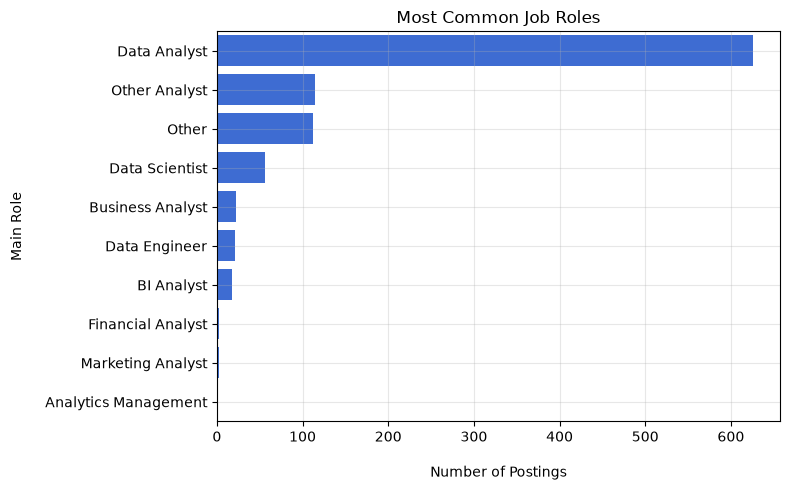

In [28]:
# --- Chart 1: Most common main roles ---
role_counts = Job_postings_raw["main_role"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=role_counts.values, y=role_counts.index, color="#2563eb", ax=ax)

ax.set_title("Most Common Job Roles")
ax.set_xlabel("Number of Postings",labelpad=15)
ax.set_ylabel("Main Role",labelpad=15)

ax.grid(True,alpha = 0.3)
fig.savefig("charts/static/most_common_roles.png", dpi=150)
fig.tight_layout()
plt.show()

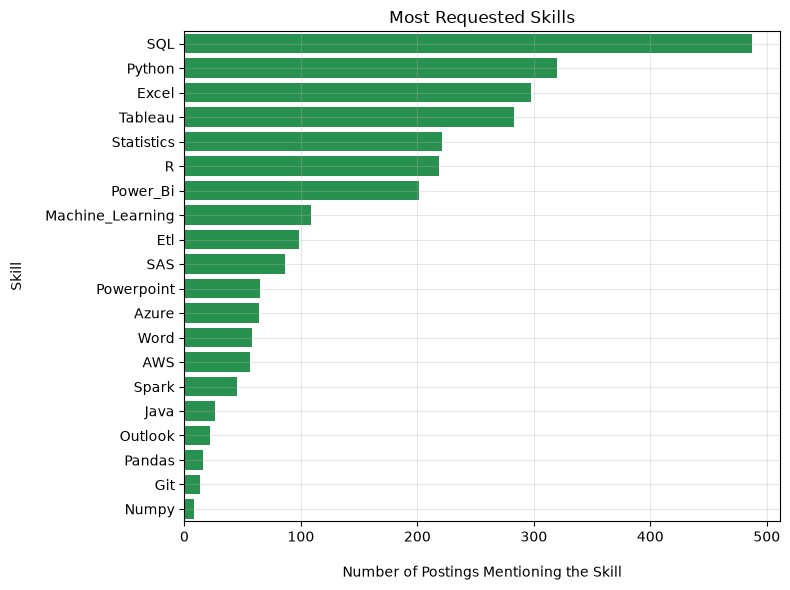

In [29]:
# --- Chart 2: Most requested skills ---
skill_columns = [skill.replace(" ", "_") for skill in skills_list]
skill_totals = Job_postings_raw[skill_columns].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=skill_totals.values, y=skill_totals.index, color="#16a34a", ax=ax)
ax.set_title("Most Requested Skills")
ax.set_xlabel("Number of Postings Mentioning the Skill",labelpad=15)
ax.set_ylabel("Skill",labelpad=15)

ax.grid(True,alpha = 0.3)
fig.savefig("charts/static/most_requested_skills.png", dpi=150)
fig.tight_layout()
plt.show()

In [30]:
print(role_counts.head(3))
print(skill_totals.head(5))

main_role
Data Analyst     626
Other Analyst    115
Other            112
Name: count, dtype: int64
SQL           487
Python        320
Excel         298
Tableau       283
Statistics    221
dtype: int64


**Observation:** Data Analyst is by far the most common role, accounting 
for 64.1% of all postings (626 out of 977), followed by titles that did 
not match a specific category ("Other Analyst" and "Other", 232 combined). 
SQL is the most requested technical skill, appearing in 49.8% of postings, 
followed by Python (32.8%) and Excel (30.5%) - showing that query and 
spreadsheet skills remain in higher demand than any single programming 
language for this role.

### 8.2 Work Mode and Seniority Distribution

Work mode explicitly mentioned in 39.3% of postings


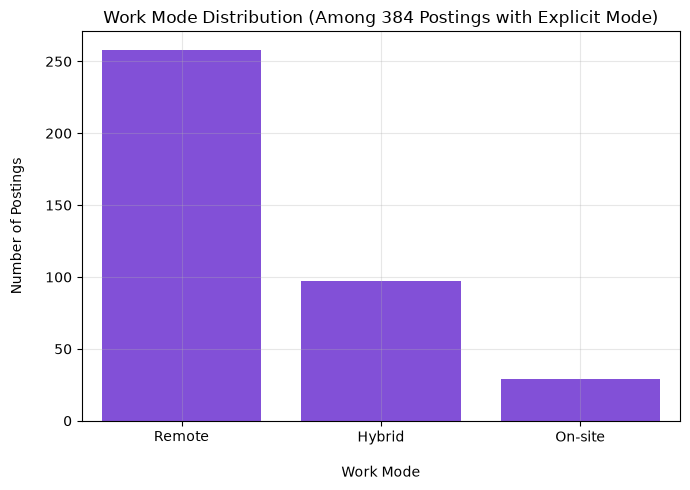

In [31]:
# --- Chart 3: Work mode distribution ---
known_mask = Job_postings_raw["work_mode_from_text"] != "Unknown"
coverage_pct = known_mask.mean() * 100
print(f"Work mode explicitly mentioned in {coverage_pct:.1f}% of postings")

known_work_mode = Job_postings_raw[known_mask]["work_mode_from_text"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=known_work_mode.index, y=known_work_mode.values, color="#7c3aed", ax=ax)

ax.set_title(f"Work Mode Distribution (Among {known_mask.sum()} Postings with Explicit Mode)")
ax.set_xlabel("Work Mode",labelpad=15)
ax.set_ylabel("Number of Postings",labelpad=15)
ax.grid(True,alpha=0.3)
fig.savefig("charts/static/work_mode_distribution.png", dpi=150)
fig.tight_layout()
plt.show()

Seniority explicitly mentioned in 22.1% of postings


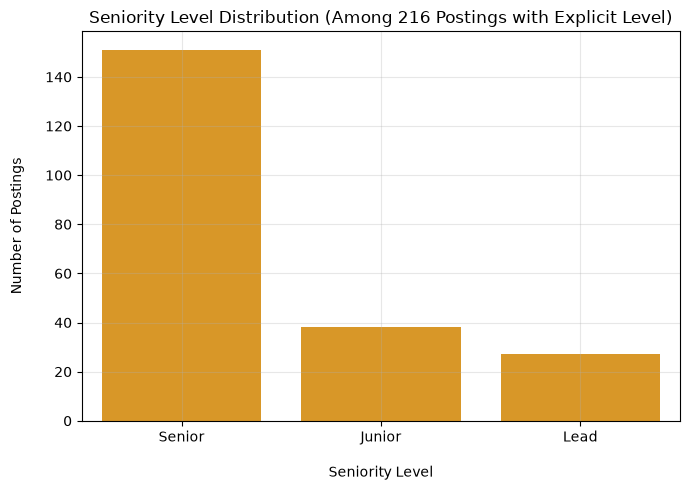

In [32]:
# --- Chart 4: Seniority level distribution ---
known_seniority_mask = Job_postings_raw["seniority_level"] != "Not Specified"
seniority_coverage = known_seniority_mask.mean() * 100
print(f"Seniority explicitly mentioned in {seniority_coverage:.1f}% of postings")

known_seniority = Job_postings_raw[known_seniority_mask]["seniority_level"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=known_seniority.index, y=known_seniority.values, color="#f59e0b", ax=ax)
ax.set_title(f"Seniority Level Distribution (Among {known_seniority_mask.sum()} Postings with Explicit Level)")
ax.set_xlabel("Seniority Level",labelpad=15)
ax.set_ylabel("Number of Postings",labelpad=15)
ax.grid(True,alpha=0.3)
fig.savefig("charts/static/seniority_distribution.png", dpi=150)

fig.tight_layout()
plt.show()

In [33]:
print(f"Work mode coverage: {coverage_pct:.1f}%")
print(known_work_mode)

print(f"Seniority coverage: {seniority_coverage:.1f}%")
print(known_seniority)

Work mode coverage: 39.3%
work_mode_from_text
Remote     258
Hybrid      97
On-site     29
Name: count, dtype: int64
Seniority coverage: 22.1%
seniority_level
Senior    151
Junior     38
Lead       27
Name: count, dtype: int64


**Observation:** Work mode is explicitly mentioned in only 39.3% of 
postings. Among those, Remote is by far the dominant mode (258 postings), 
followed by Hybrid (97) and On-site (29) - suggesting that when companies 
do specify a work arrangement, remote positions are the most common by 
a wide margin. Similarly, seniority level is explicitly stated in only 
22.1% of titles, with Senior positions (151) far outnumbering Junior (38) 
and Lead (27) roles among those that do specify a level.

### 8.3 Salary Distribution and Experience-Salary Relationship

Salary analysis based on 152 out of 977 postings


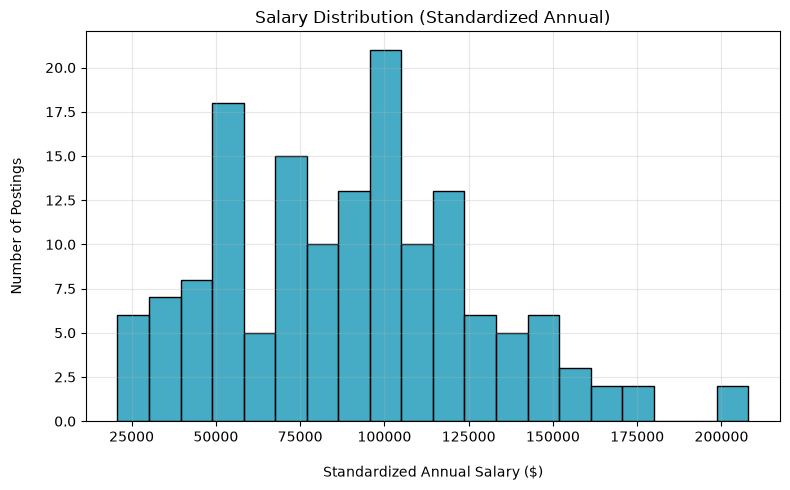

In [34]:
# --- Chart 5: Salary distribution (only on postings with disclosed salary) ---
salary_data = Job_postings_raw[Job_postings_raw["has_salary"]]
print(f"Salary analysis based on {len(salary_data)} out of {len(Job_postings_raw)} postings")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(salary_data["salary_standardized"], bins=20, color="#0891b2", ax=ax)
ax.set_title("Salary Distribution (Standardized Annual)")
ax.set_xlabel("Standardized Annual Salary ($)",labelpad=15)
ax.set_ylabel("Number of Postings",labelpad=15)
ax.grid(True,alpha=0.3)
fig.savefig("charts/static/salary_distribution.png", dpi=150)
fig.tight_layout()
plt.show()

### Observation

- Salary analysis is based on **152 postings** that contained usable salary information.
- Most standardized annual salaries fall between **$70,000 and $120,000**.
- The salary distribution is **right-skewed**, with a small number of high-paying positions above **$150,000**.
- Very high salaries are relatively rare compared to mid-range salaries.
- Only **152 out of 977 postings** included salary information, indicating that salary data is missing for a large portion of the dataset.

Experience-salary relationship based on 65 postings


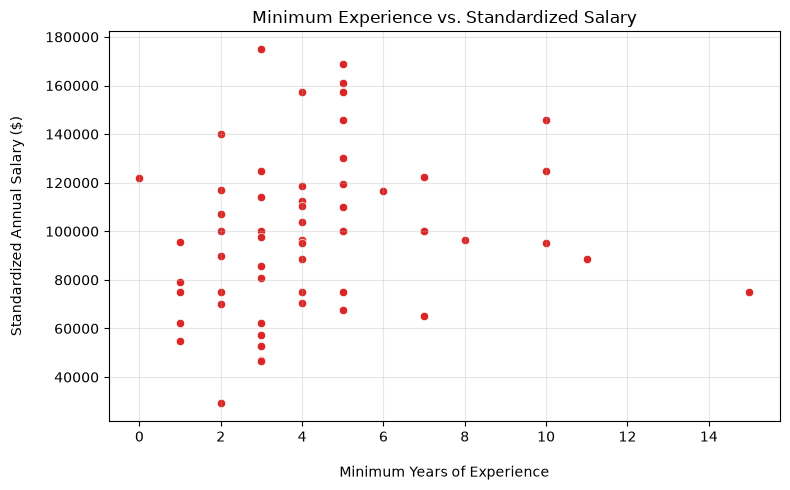

In [35]:
# --- Chart 6: Experience vs Salary relationship ---
exp_salary_data = salary_data[salary_data["min_experience"].notna()]
print(f"Experience-salary relationship based on {len(exp_salary_data)} postings")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=exp_salary_data,
    x="min_experience",
    y="salary_standardized",
    color="#dc2626",
    ax=ax
)
ax.set_title("Minimum Experience vs. Standardized Salary")
ax.set_xlabel("Minimum Years of Experience",labelpad=15)
ax.set_ylabel("Standardized Annual Salary ($)",labelpad=15)
ax.grid(True,alpha=0.3)
fig.savefig("charts/static/experience_vs_salary.png", dpi=150)
fig.tight_layout()
plt.show()

### Observation
- The analysis includes 65 job postings with both salary and extracted experience data.
- Most jobs require between **2 and 5 years** of minimum experience.
- Salaries show a **wide variation** even for the same experience level.
- A weak positive relationship is observed, where higher experience generally tends to be associated with higher salaries, although the trend is not consistent.
- The spread of salaries suggests that factors other than experience (such as role, company, location, and required skills) also influence compensation.

In [36]:
salary_data["salary_standardized"].describe()

count       152.000000
mean      90287.168520
std       38186.674334
min       20800.000000
25%       57425.000000
50%       93600.000000
75%      114400.000000
max      208000.000000
Name: salary_standardized, dtype: float64

### 8.4 Skill Co-occurrence Analysis

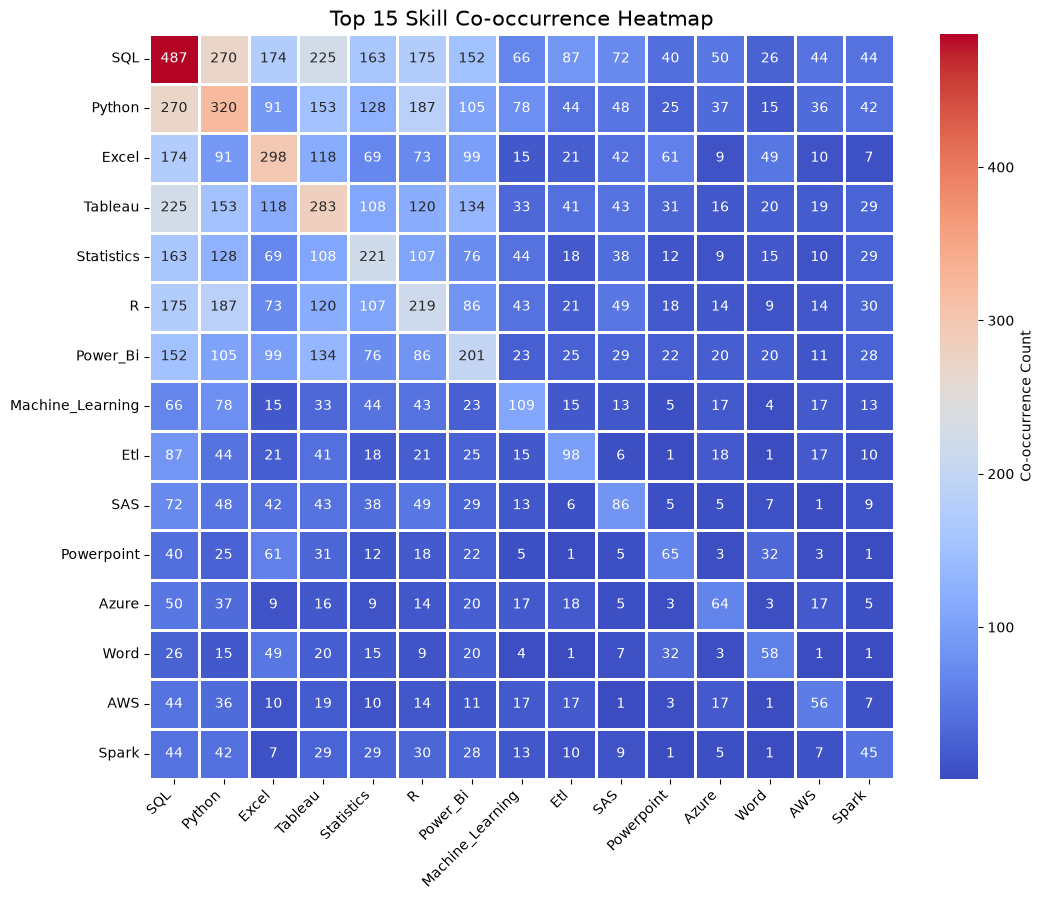

In [37]:

# Technical skill columns
skill_cols = [
    'Python', 'SQL', 'Excel', 'Power_Bi', 'Tableau',
    'Pandas', 'Numpy', 'Machine_Learning', 'Git',
    'AWS', 'Azure', 'R', 'Java', 'SAS',
    'Spark', 'Etl', 'Statistics',
    'Powerpoint', 'Word', 'Outlook'
]

# Select the 15 most frequently requested skills
top_skills = (
    Job_postings_raw[skill_cols]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Build co-occurrence matrix
co_occurrence = Job_postings_raw[top_skills].T.dot(
    Job_postings_raw[top_skills]
)

plt.figure(figsize=(11,9))

sns.heatmap(
    co_occurrence,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    square=True,
    linewidths=0.8,
    cbar_kws={"label":"Co-occurrence Count"}
)

plt.title("Top 15 Skill Co-occurrence Heatmap", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig("charts/static/skill_co_occurrence_heatmap.png", dpi=150)
plt.tight_layout()
plt.show()

**Note:** The diagonal values represent the total count of each skill 
(e.g., SQL appears in 487 postings), while off-diagonal values show how 
often two skills appear together in the same posting.

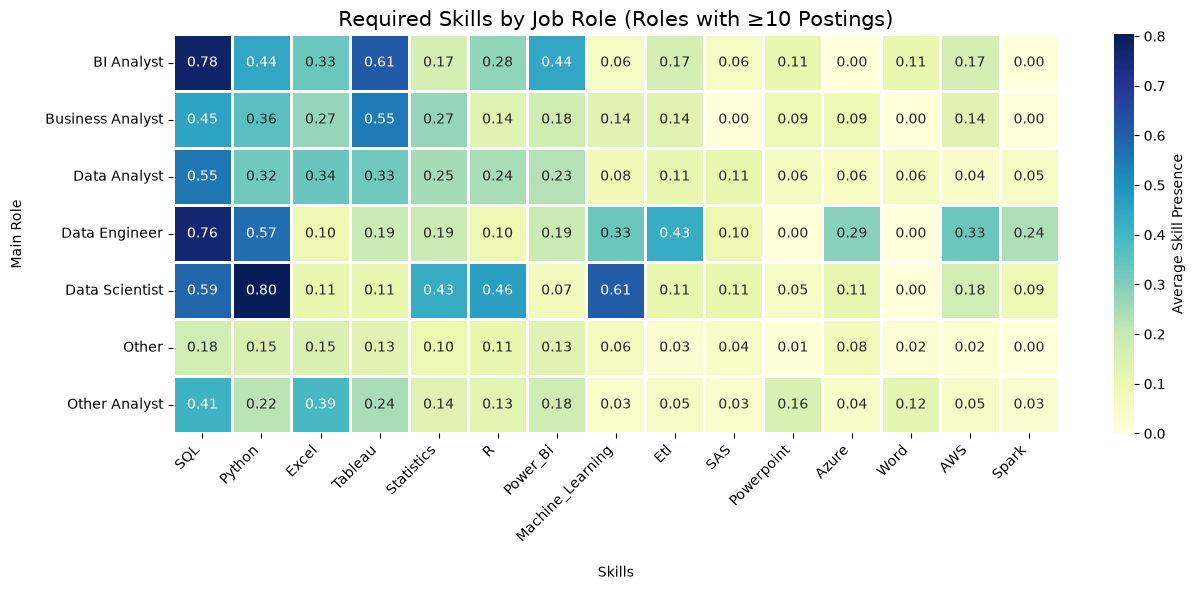

In [38]:
# Only include roles with a reasonable number of postings (avoid misleading 100%/0% from tiny samples)
role_counts_for_heatmap = Job_postings_raw["main_role"].value_counts()
reliable_roles = role_counts_for_heatmap[role_counts_for_heatmap >= 10].index

role_skill = (
    Job_postings_raw[Job_postings_raw["main_role"].isin(reliable_roles)]
    .groupby("main_role")[top_skills]
    .mean()
)

plt.figure(figsize=(13, 6))
sns.heatmap(
    role_skill, 
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.8,
    cbar_kws={"label": "Average Skill Presence"}
    )

plt.title("Required Skills by Job Role (Roles with ≥10 Postings)", fontsize=15)
plt.xlabel("Skills",labelpad=15)
plt.ylabel("Main Role",labelpad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("charts/static/role_skill_heatmap.png", dpi=150)
plt.show()

**Note:** Roles with fewer than 10 postings (e.g., Financial Analyst, 
Marketing Analyst, Healthcare Analyst) were excluded from this comparison, 
as their small sample size would produce misleading 100%/0% values.

### 8.5 Top Hiring Companies and Locations

In [39]:

top_companies = (
    Job_postings_raw["company"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_companies.columns = ["Company", "Job Postings"]

fig = px.bar(
    top_companies,
    x="Job Postings",
    y="Company",
    orientation="h",
    color="Job Postings",
    title="Top 15 Hiring Companies"
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    template="plotly_white"
)

fig.write_html("charts/interactive/top_hiring_companies.html")
fig.show()

**Note:** Some of the top entries (e.g., "Upwork", "Dice", "Insight Global") 
are hiring/staffing platforms or recruitment agencies rather than the 
direct employer, and "Corporate" appears to be a generic placeholder in 
the source data rather than an actual company name. This should be 
considered when interpreting hiring volume by company.

In [40]:
# Separate "Anywhere" (remote indicator) from actual geographic locations
location_data = Job_postings_raw["location"].replace({"Anywhere": "Remote (Anywhere)"})
top_locations = location_data.value_counts().head(15).reset_index()
top_locations.columns = ["Location", "Job Postings"]

fig = px.bar(
    top_locations,
    x="Location",
    y="Job Postings",
    color="Job Postings",
    title="Top 15 Hiring Locations",
    template="plotly_white"
)

fig.write_html("charts/interactive/top_hiring_locations.html")
fig.show()

**Note:** "Anywhere" represents remote postings without a specific 
location, while "United States" reflects country-level postings without 
a specific city. Both are shown alongside specific cities for completeness, 
though they represent a different level of geographic detail.

### 8.6 Skills vs Salary Comparison

In [41]:
skills_to_compare = ["Python", "SQL", "Machine_Learning", "Power_Bi", "Tableau"]

for skill in skills_to_compare:
    n_has = (salary_data[skill] == 1).sum()
    n_no = (salary_data[skill] == 0).sum()
    print(f"{skill}: {n_has} with skill, {n_no} without")

Python: 37 with skill, 115 without
SQL: 66 with skill, 86 without
Machine_Learning: 15 with skill, 137 without
Power_Bi: 28 with skill, 124 without
Tableau: 42 with skill, 110 without


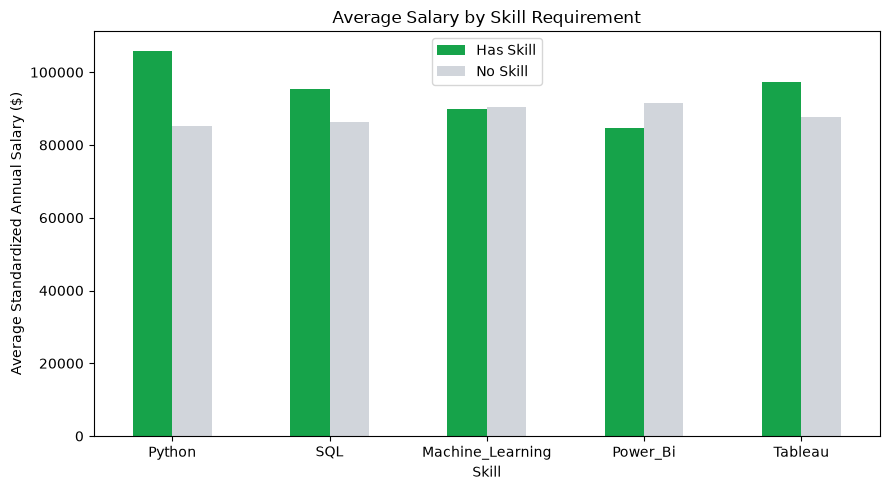

In [42]:
skills_to_compare = ["Python", "SQL", "Machine_Learning", "Power_Bi", "Tableau"]

salary_by_skill = {}
for skill in skills_to_compare:
    has_skill_salary = salary_data[salary_data[skill] == 1]["salary_standardized"].mean()
    no_skill_salary = salary_data[salary_data[skill] == 0]["salary_standardized"].mean()
    salary_by_skill[skill] = {"Has Skill": has_skill_salary, "No Skill": no_skill_salary}

salary_skill_df = pd.DataFrame(salary_by_skill).T

fig, ax = plt.subplots(figsize=(9, 5))
salary_skill_df.plot(kind="bar", ax=ax, color=["#16a34a", "#d1d5db"])
ax.set_title("Average Salary by Skill Requirement")
ax.set_xlabel("Skill")
ax.set_ylabel("Average Standardized Annual Salary ($)")
ax.legend(title="")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig("charts/static/salary_by_skill.png", dpi=150)
plt.show()

**Observation:** Postings requiring Python show the highest average salary 
premium (~$106,000 vs. ~$85,000 for those without it), followed by 
Tableau and SQL, both associated with roughly $9,000-$10,000 higher 
average salaries. Interestingly, Power BI shows a slightly lower average 
salary compared to postings without it, and Machine Learning shows almost 
no difference - though this result should be interpreted with caution 
given the smaller sample size for Machine Learning (15 postings). Overall, 
programming and analytical tool skills (Python, SQL, Tableau) appear more 
strongly associated with higher compensation than software-specific 
skills like Power BI in this sample.

**Caution:** These comparisons are based on relatively small samples 
(all under 70 postings per group) and should be treated as indicative 
trends rather than statistically robust conclusions.

## 9. Final Findings

1. **Data Analyst dominates the job market in this sample**, accounting 
   for 64.1% of all postings (626 out of 977). This reflects the 
   dataset's focus on this role, with Data Scientist (56), Business 
   Analyst (22), and Data Engineer (21) appearing far less frequently.

2. **SQL is the most in-demand technical skill**, appearing in 49.8% of 
   postings, followed by Python (32.8%) and Excel (30.5%). This suggests 
   that query and data-handling skills are valued at least as highly as 
   programming languages for data roles.

3. **SQL and Python frequently co-occur** in the same job postings, 
   confirming that most data roles expect a combination of database 
   querying and programming skills rather than either skill in isolation.

4. **Work mode is rarely specified explicitly** (only 39.3% of postings), 
   but among those that do specify it, Remote positions dominate (258 
   postings) compared to Hybrid (97) and On-site (29) - suggesting a 
   strong employer preference for remote arrangements when stated.

5. **Seniority level is stated in only 22.1% of job titles**, with 
   Senior roles (151) far outnumbering Junior (38) and Lead (27) - 
   indicating most postings target broad experience ranges rather than 
   entry-level or leadership-specific candidates.

6. **Salary information is disclosed in only 15.6% of postings** (152 out 
   of 977), with a median standardized annual salary of ~$93,600 
   (range: $20,800-$208,000). The distribution is right-skewed, with a 
   small number of high-paying positions above $150,000.

7. **Python is associated with the highest average salary premium** 
   (~$106,000 vs. ~$85,000 for postings without it), followed by 
   Tableau and SQL (~$9,000-$10,000 premium each). Machine Learning and 
   Power BI showed little to no salary advantage in this sample, though 
   results should be interpreted cautiously given small sample sizes.

## 10. Limitations

- **Sample size:** Analysis is based on a random sample of 977 postings 
  out of 61,953 available in the original Kaggle dataset, for processing 
  efficiency. Findings may not generalize to the full dataset.
- **Salary coverage:** Only 15.6% of postings disclosed salary 
  information; no values were invented for the remaining postings, and 
  salary-related findings are based on this smaller subset only.
- **Experience extraction:** Years of experience were successfully 
  extracted from 56.7% of postings using regex on free-text descriptions; 
  the remainder did not mention experience explicitly.
- **Work mode / seniority coverage:** Work mode was identifiable in 39.3% 
  of postings and seniority in only 22.1%, both based on explicit 
  mentions in the job description or title.
- **Role classification:** 23.2% of job titles did not match a specific 
  predefined role category (classified as "Other"/"Other Analyst"), 
  mostly due to vague, non-English, or highly unique titles.
- **Company/location granularity:** Some top "companies" are staffing 
  platforms (e.g., Upwork, Dice) rather than direct employers, and 
  "Anywhere"/"United States" mix remote and country-level entries with 
  specific city-level locations.
- **Small comparison groups:** Skill-salary comparisons are based on 
  relatively small samples (all under 70 postings per group) and should 
  be treated as indicative trends, not statistically robust conclusions.